# PFSS Time-Series Backmapping: Solar Orbiter (2022-03-02 to 2022-03-07)

Pipeline:
1. **SC → Source Surface**: Parker spiral backmapping using `backmapping_angle()` with real Vsw
2. **Source Surface → Photosphere**: PFSS field line tracing (HMI synoptic CR2254)
3. **Visualization**: Synoptic map + AIA 171Å overlay, color-coded by time

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize

import astropy.units as u
from astropy.coordinates import SkyCoord, Longitude
from astropy.time import Time

import sunpy.map
from sunpy.coordinates import get_earth, HeliographicCarrington
from sunpy.coordinates.ephemeris import get_horizons_coord

from sunkit_magex import pfss
from sunkit_magex.pfss import tracing

from solarmach import backmapping_angle, get_sw_speed

# Paths
DATA_DIR = (Path.cwd().parent / 'data').resolve()
RESULTS_DIR = (Path.cwd().parent / 'results').resolve()
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Data: {DATA_DIR}\nResults: {RESULTS_DIR}")

Data: /disk/plasma/xw2/PFSS/data
Results: /disk/plasma/xw2/PFSS/results


## Step 1: Fetch Solar Orbiter ephemeris (bulk HORIZONS call)

In [28]:
# Bulk fetch Solar Orbiter positions (single HORIZONS request)
solo_coords = get_horizons_coord('Solar Orbiter', time={
    'start': '2022-03-02 06:00',
    'stop': '2022-03-07 00:00',
    'step': '12h'
})

# Transform to Carrington (observer='Sun', matching SolarMACH convention)
solo_carr = solo_coords.transform_to(HeliographicCarrington(observer='Sun'))

# Extract arrays
times = solo_carr.obstime
solo_lon = solo_carr.lon
solo_lat = solo_carr.lat
solo_dist = solo_carr.radius.to(u.AU)

print(f"Fetched {len(times)} timestamps: {times[0].iso} to {times[-1].iso}")
print(f"Lon range: {solo_lon.min():.1f} to {solo_lon.max():.1f}")
print(f"Dist range: {solo_dist.min():.3f} to {solo_dist.max():.3f}")

2026-03-31 23:08:01 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
Fetched 10 timestamps: 2022-03-02 06:00:00.000 to 2022-03-06 18:00:00.000
Lon range: 8.7 deg to 61.6 deg
Dist range: 0.505 AU to 0.561 AU


## Step 2: Get real Vsw for each timestamp

In [29]:
# Fetch measured solar wind speed for each timestamp
# get_sw_speed uses speasy/OMNI; falls back to default_vsw if unavailable
vsw_list = []
for i, t in enumerate(times):
    v = get_sw_speed('Solar Orbiter', t.datetime, default_vsw=400.0, silent=True)
    vsw_list.append(v)
    if (i + 1) % 10 == 0:
        print(f"  Fetched {i + 1}/{len(times)} Vsw values...")

vsw = np.array(vsw_list) * u.km / u.s
print(f"\nVsw range: {vsw.min():.0f} to {vsw.max():.0f}")
print(f"Vsw mean: {vsw.mean():.0f}")

  Fetched 10/10 Vsw values...

Vsw range: 338 km / s to 570 km / s
Vsw mean: 469 km / s


## Step 3: Parker spiral backmapping (SC → Source Surface)

In [30]:
# Parker spiral backmapping: SC → Source Surface at 2.5 Rs
rss = 2.5

# backmapping_angle accepts arrays — vectorized, no loop needed
alpha = backmapping_angle(
    solo_dist, rss * u.R_sun, solo_lat, vsw, diff_rot=True
).to(u.deg)

ss_lon = (Longitude(solo_lon) + alpha).wrap_at(360 * u.deg)
ss_lat = solo_lat  # latitude unchanged in radial Parker spiral

# Build summary DataFrame
df = pd.DataFrame({
    'time': [t.iso for t in times],
    'sc_lon_deg': solo_lon.to(u.deg).value,
    'sc_lat_deg': solo_lat.to(u.deg).value,
    'sc_dist_AU': solo_dist.value,
    'vsw_km_s': vsw.value,
    'alpha_deg': alpha.value,
    'ss_lon_deg': ss_lon.to(u.deg).value,
    'ss_lat_deg': ss_lat.to(u.deg).value,
})
df

,time,sc_lon_deg,sc_lat_deg,sc_dist_AU,vsw_km_s,alpha_deg,ss_lon_deg,ss_lat_deg
0,2022-03-02 06:00:00.000,61.595567,-4.084653,0.561100,467.396912,29.410311,91.005878,-4.084653
1,2022-03-02 18:00:00.000,55.613333,-4.111851,0.554918,450.782104,30.149792,85.763125,-4.111851
2,2022-03-03 06:00:00.000,49.656244,-4.138073,0.548707,517.204285,25.976219,75.632462,-4.138073
3,2022-03-03 18:00:00.000,43.725276,-4.163221,0.542471,525.110962,25.286866,69.012142,-4.163221
4,2022-03-04 06:00:00.000,37.821449,-4.187192,0.536209,569.658203,23.033523,60.854972,-4.187192
5,2022-03-04 18:00:00.000,31.945827,-4.209871,0.529926,519.322876,24.962393,56.908220,-4.209871
6,2022-03-05 06:00:00.000,26.099521,-4.231135,0.523622,477.111145,26.839427,52.938949,-4.231135
7,2022-03-05 18:00:00.000,20.283690,-4.250851,0.517301,409.647675,30.872494,51.156184,-4.250851
8,2022-03-06 06:00:00.000,14.499541,-4.268874,0.510965,417.864441,29.885239,44.384780,-4.268874
9,2022-03-06 18:00:00.000,8.748330,-4.285050,0.504618,338.230957,36.451031,45.199361,-4.285050


## Step 4: Load HMI synoptic map + compute PFSS

In [8]:
# Load HMI synoptic magnetogram (CR 2254, covers full date range)
hmi_synop = sunpy.map.Map(DATA_DIR / 'hmi.synoptic_mr_polfil_720s.2254.Mr_polfil.fits')

# Fix missing metadata
earth_coord = get_earth(hmi_synop.date)
hmi_synop.meta['dsun_obs'] = earth_coord.radius.to('m').value
hmi_synop.meta['hgln_obs'] = earth_coord.lon.to('deg').value
hmi_synop.meta['hglt_obs'] = earth_coord.lat.to('deg').value

# Resample and compute PFSS (single solve for all timestamps)
hmi_synop_resample = hmi_synop.resample([720, 360] * u.pix)

nrho = 25
pfss_input = pfss.Input(hmi_synop_resample, nrho, rss)
pfss_out = pfss.pfss(pfss_input)

print(f"PFSS coordinate_frame obstime: {pfss_out.coordinate_frame.obstime}")
print(f"PFSS grid shape: {pfss_out.grid.rg.shape}")

2026-03-31 21:51:49 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 21:51:49 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
PFSS coordinate_frame obstime: 2022-02-21T20:07:23.000
PFSS grid shape: (26,)


## Step 5: Trace field lines from SS → Photosphere

CRITICAL: Seeds must use `pfss_out.coordinate_frame` to avoid obstime mismatch.
The PFSS frame has obstime ~2022-02-21 (synoptic map). If we used the SC observation time instead, the tracer would shift longitudes by solar rotation over ~10 days.

In [31]:
# Create seeds at source surface using PFSS coordinate frame
seeds = SkyCoord(
    lon=ss_lon,
    lat=ss_lat,
    radius=np.ones(len(ss_lon)) * rss * u.R_sun,
    frame=pfss_out.coordinate_frame  # CRITICAL: match PFSS obstime
)

# Trace field lines (bidirectional: SS ↔ photosphere)
tracer = tracing.PerformanceTracer()
flines = tracer.trace(seeds, pfss_out)

print(f"Traced {len(flines)} field lines")
for pol_val, pol_name in [(1, 'Open (+)'), (-1, 'Open (-)'), (0, 'Closed')]:
    n = sum(1 for f in flines if f.polarity == pol_val)
    if n > 0:
        print(f"  {pol_name}: {n}")

Traced 10 field lines
  Open (-): 10


## Step 6: Extract footpoints + result table

In [32]:
def extract_footpoints(flines):
    """Extract photosphere and source surface footpoints from field lines."""
    solar_footpoints = []
    ss_footpoints = []
    polarities = []
    for fline in flines:
        polarities.append(fline.polarity)
        solar_footpoints.append(fline.solar_footpoint)
        ss_footpoints.append(fline.source_surface_footpoint)
    return solar_footpoints, ss_footpoints, polarities

solar_fps, ss_fps, polarities = extract_footpoints(flines)

# Add footpoint info to DataFrame
df['polarity'] = polarities
df['solar_fp_lon_deg'] = [
    fp.lon.to(u.deg).value if fp is not None else np.nan for fp in solar_fps
]
df['solar_fp_lat_deg'] = [
    fp.lat.to(u.deg).value if fp is not None else np.nan for fp in solar_fps
]

print("Summary:")
print(df[['time', 'vsw_km_s', 'ss_lon_deg', 'ss_lat_deg',
          'solar_fp_lon_deg', 'solar_fp_lat_deg', 'polarity']].to_string())

Summary:
                      time    vsw_km_s  ss_lon_deg  ss_lat_deg  solar_fp_lon_deg  solar_fp_lat_deg  polarity
0  2022-03-02 06:00:00.000  467.396912   91.005878   -4.084653         49.311626        -13.836039      -1.0
1  2022-03-02 18:00:00.000  450.782104   85.763125   -4.111851         48.373477        -13.967987      -1.0
2  2022-03-03 06:00:00.000  517.204285   75.632462   -4.138073         48.183848        -14.153214      -1.0
3  2022-03-03 18:00:00.000  525.110962   69.012142   -4.163221         48.008022        -14.036794      -1.0
4  2022-03-04 06:00:00.000  569.658203   60.854972   -4.187192         47.886140        -14.130403      -1.0
5  2022-03-04 18:00:00.000  519.322876   56.908220   -4.209871         48.129926        -13.536577      -1.0
6  2022-03-05 06:00:00.000  477.111145   52.938949   -4.231135         47.825375        -14.083920      -1.0
7  2022-03-05 18:00:00.000  409.647675   51.156184   -4.250851         47.863289        -14.112232      -1.0
8  2022-03

## Plot 1: Synoptic map with time-colored footpoints and field lines

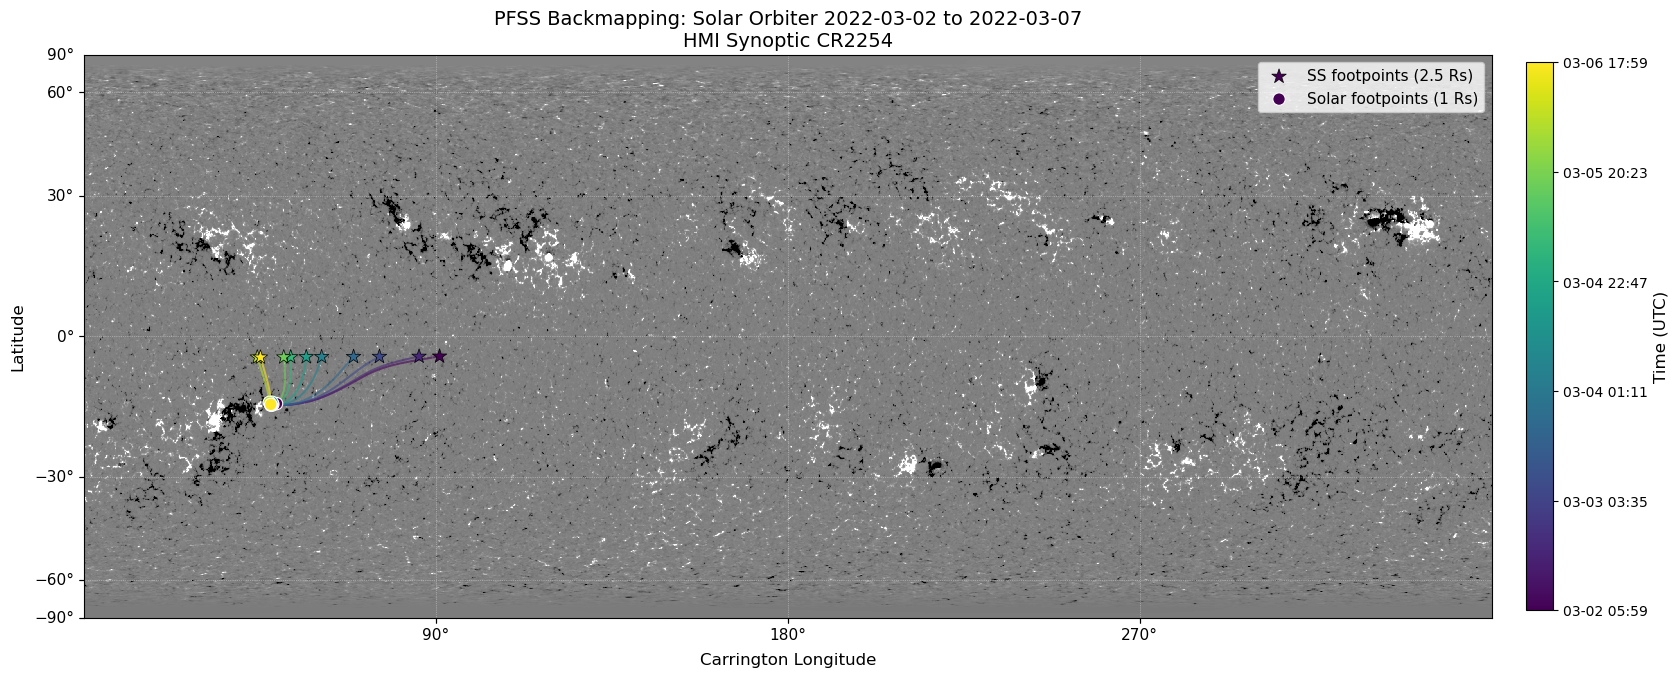

In [35]:
# Time-based colormap
times_mjd = np.array([t.mjd for t in times])
norm = Normalize(vmin=times_mjd.min(), vmax=times_mjd.max())
cmap = plt.cm.viridis
colors = cmap(norm(times_mjd))

# --- Plot ---
plt.close('all')
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(111, projection=hmi_synop)

hmi_synop.plot_settings['cmap'] = 'gray'
hmi_synop.plot_settings['norm'] = Normalize(vmin=-100, vmax=100)
im = hmi_synop.plot(axes=ax)

# Field lines, colored by time
for i, fline in enumerate(flines):
    coords = fline.coords
    lons = coords.lon.to(u.deg).value
    lats = coords.lat.to(u.deg).value
    px, py = hmi_synop.wcs.world_to_pixel_values(lons, lats)
    ax.plot(px, py, color=colors[i], alpha=0.6, linewidth=1.5)

# SS footpoints (stars)
ss_lons_val = ss_lon.to(u.deg).value
ss_lats_val = ss_lat.to(u.deg).value
ss_px, ss_py = hmi_synop.wcs.world_to_pixel_values(ss_lons_val, ss_lats_val)
ax.scatter(ss_px, ss_py, c=times_mjd, cmap=cmap, norm=norm,
           marker='*', s=120, edgecolors='black', linewidths=0.5,
           zorder=5, label='SS footpoints (2.5 Rs)')

# Solar surface footpoints (circles)
solar_fp_lons = np.array(df['solar_fp_lon_deg'])
solar_fp_lats = np.array(df['solar_fp_lat_deg'])
valid = ~np.isnan(solar_fp_lons)
if valid.any():
    sfp_px, sfp_py = hmi_synop.wcs.world_to_pixel_values(
        solar_fp_lons[valid], solar_fp_lats[valid]
    )
    ax.scatter(sfp_px, sfp_py, c=times_mjd[valid], cmap=cmap, norm=norm,
               marker='o', s=80, edgecolors='white', linewidths=0.8,
               zorder=5, label='Solar footpoints (1 Rs)')

# Colorbar with date labels
sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm_cb, ax=ax, shrink=0.6, pad=0.02)
# Convert MJD ticks to date strings
cbar_ticks = np.linspace(times_mjd.min(), times_mjd.max(), 6)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([Time(t, format='mjd').datetime.strftime('%m-%d %H:%M') for t in cbar_ticks])
cbar.set_label('Time (UTC)', fontsize=12)

ax.legend(loc='upper right', fontsize=11)
ax.set_title('PFSS Backmapping: Solar Orbiter 2022-03-02 to 2022-03-07\n'
             'HMI Synoptic CR2254', fontsize=14)
ax.set_xlabel('Carrington Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/backmapping_timeseries_synoptic.png', dpi=300)

## Plot 1b: Zoomed synoptic map (lon 30-80, lat -30 to 20)

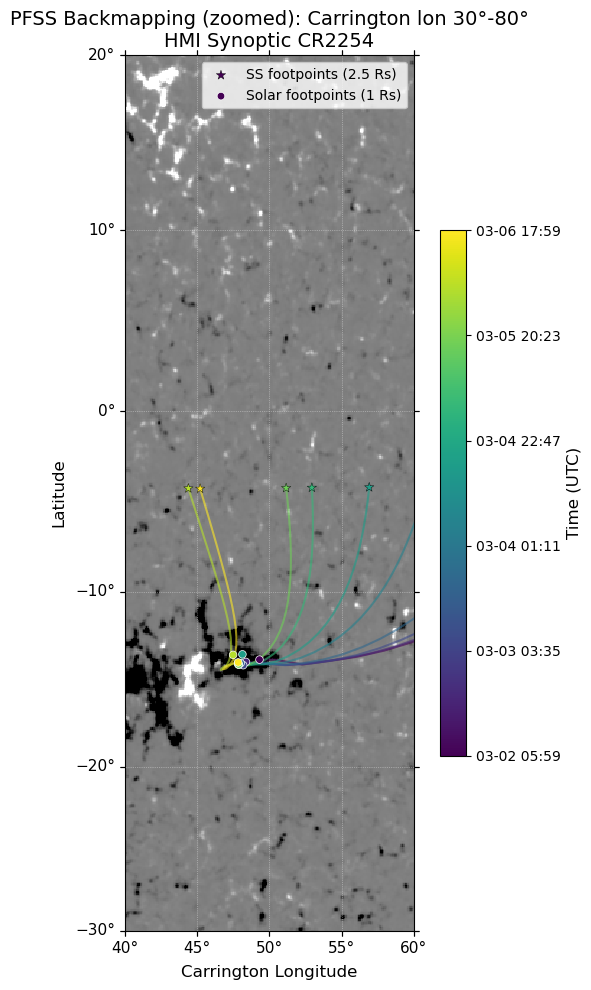

In [36]:
# Zoomed synoptic map
plt.close('all')
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection=hmi_synop)

hmi_synop.plot_settings['cmap'] = 'gray'
hmi_synop.plot_settings['norm'] = Normalize(vmin=-100, vmax=100)
im = hmi_synop.plot(axes=ax)

# Field lines, colored by time
for i, fline in enumerate(flines):
    coords = fline.coords
    lons = coords.lon.to(u.deg).value
    lats = coords.lat.to(u.deg).value
    px, py = hmi_synop.wcs.world_to_pixel_values(lons, lats)
    ax.plot(px, py, color=colors[i], alpha=0.6, linewidth=1.5)

# SS footpoints (stars) - smaller markers
ss_px, ss_py = hmi_synop.wcs.world_to_pixel_values(ss_lons_val, ss_lats_val)
ax.scatter(ss_px, ss_py, c=times_mjd, cmap=cmap, norm=norm,
           marker='*', s=50, edgecolors='black', linewidths=0.3,
           zorder=5, label='SS footpoints (2.5 Rs)')

# Solar surface footpoints (circles) - smaller markers
solar_fp_lons = np.array(df['solar_fp_lon_deg'])
solar_fp_lats = np.array(df['solar_fp_lat_deg'])
valid = ~np.isnan(solar_fp_lons)
if valid.any():
    sfp_px, sfp_py = hmi_synop.wcs.world_to_pixel_values(
        solar_fp_lons[valid], solar_fp_lats[valid]
    )
    ax.scatter(sfp_px, sfp_py, c=times_mjd[valid], cmap=cmap, norm=norm,
               marker='o', s=30, edgecolors='white', linewidths=0.5,
               zorder=5, label='Solar footpoints (1 Rs)')

# Zoom to specified region: lon [40, 60], lat [-30, 20]
# Carrington synoptic map: larger lon on left, smaller on right
px_left, py_bot = hmi_synop.wcs.world_to_pixel_values(60, -30)
px_right, py_top = hmi_synop.wcs.world_to_pixel_values(40, 20)
ax.set_xlim(min(px_left, px_right), max(px_left, px_right))
ax.set_ylim(min(py_bot, py_top), max(py_bot, py_top))

# Colorbar with date labels
sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm_cb, ax=ax, shrink=0.6, pad=0.02)
cbar_ticks = np.linspace(times_mjd.min(), times_mjd.max(), 6)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([Time(t, format='mjd').datetime.strftime('%m-%d %H:%M') for t in cbar_ticks])
cbar.set_label('Time (UTC)', fontsize=12)

ax.legend(loc='upper right', fontsize=10)
ax.set_title('PFSS Backmapping (zoomed): Carrington lon 30\u00b0-80\u00b0\n'
             'HMI Synoptic CR2254', fontsize=14)
ax.set_xlabel('Carrington Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/backmapping_timeseries_synoptic_zoom.png', dpi=300)

## Plot 2: AIA 171Å map with solar surface footpoints

Coordinate fix: field line coords from PFSS have obstime ~Feb 21 (synoptic map). To plot on AIA (obstime Mar 3), we recreate coords with AIA's obstime before transforming to HPC. This prevents solar rotation offset.

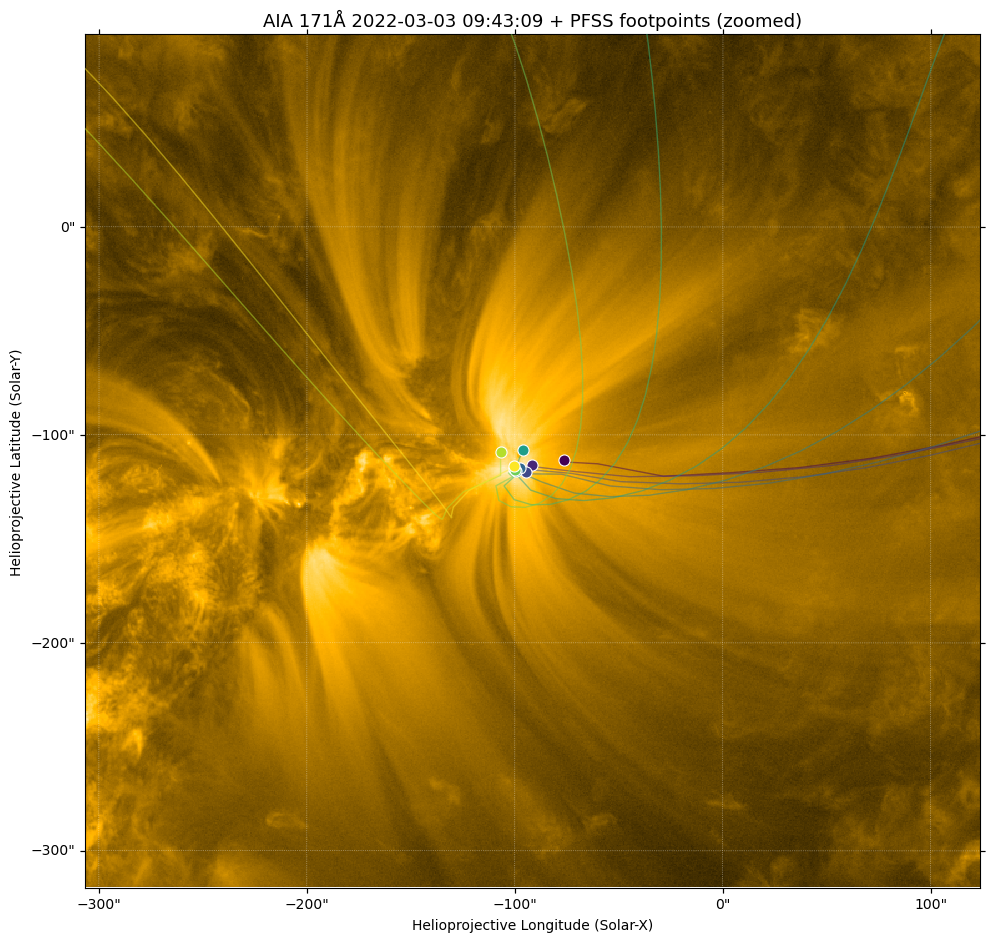

In [37]:
# Load AIA 171 map
aia_map = sunpy.map.Map(DATA_DIR / 'aia.lev1.171A_2022_03_03T09_43_09.34Z.image_lev1.fits')
obs_time = aia_map.date

plt.close('all')
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=aia_map)
aia_map.plot(axes=ax)

# Plot field lines on AIA (with obstime correction)
for i, fline in enumerate(flines):
    coords = fline.coords
    # Recreate in HGC with AIA's obstime to prevent rotation offset
    coords_corrected = SkyCoord(
        lon=coords.lon,
        lat=coords.lat,
        radius=coords.radius,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time)
    )
    coords_hpc = coords_corrected.transform_to(aia_map.coordinate_frame)

    # Filter to on-disk points only
    on_disk = (np.abs(coords_hpc.Tx) < 1200 * u.arcsec) & \
              (np.abs(coords_hpc.Ty) < 1200 * u.arcsec)
    if on_disk.any():
        ax.plot_coord(coords_hpc[on_disk], color=colors[i], alpha=0.5, linewidth=1)

# Plot solar footpoints on AIA
fp_hpc_list = []
for i, fp in enumerate(solar_fps):
    if fp is None:
        continue
    fp_corrected = SkyCoord(
        lon=fp.lon, lat=fp.lat, radius=1.0 * u.R_sun,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time)
    )
    fp_hpc = fp_corrected.transform_to(aia_map.coordinate_frame)
    fp_hpc_list.append(fp_hpc)
    # Only plot if on disk
    if np.abs(fp_hpc.Tx) < 1200 * u.arcsec and np.abs(fp_hpc.Ty) < 1200 * u.arcsec:
        ax.plot_coord(fp_hpc, marker='o', color=colors[i], markersize=8,
                      markeredgecolor='white', markeredgewidth=0.8)

# Zoom in to footpoint region with padding
if fp_hpc_list:
    all_tx = u.Quantity([fp.Tx for fp in fp_hpc_list])
    all_ty = u.Quantity([fp.Ty for fp in fp_hpc_list])
    pad = 200 * u.arcsec
    tx_min, tx_max = all_tx.min() - pad, all_tx.max() + pad
    ty_min, ty_max = all_ty.min() - pad, all_ty.max() + pad
    # Convert to pixel for set_xlim/set_ylim
    bl = aia_map.wcs.world_to_pixel(SkyCoord(tx_min, ty_min, frame=aia_map.coordinate_frame))
    tr = aia_map.wcs.world_to_pixel(SkyCoord(tx_max, ty_max, frame=aia_map.coordinate_frame))
    ax.set_xlim(bl[0], tr[0])
    ax.set_ylim(bl[1], tr[1])

ax.set_title(f'AIA 171\u00c5 {obs_time.iso[:19]} + PFSS footpoints (zoomed)', fontsize=13)

plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/backmapping_timeseries_aia171_zoom.png', dpi=300)

## Plot 3: AIA 171Å reprojected to Carrington (flat view around footpoints)

Reproject AIA from Helioprojective (disk view) to Heliographic Carrington (flat lat/lon map), zoomed to the footpoint region. This removes foreshortening near the limb and shows the source region in a geographic-style projection.

Footpoint region: lon=44.4-91.0, lat=-14.2--4.1
Map center: (67.7, -9.1), range: 67 x 30 deg
Output shape: (601, 1332)


2026-03-31 23:09:41 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:09:41 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:09:41 - sunpy - WARNING: SunpyUserWarning: rsun mismatch detected: AIA 171.0 Angstrom 2022-03-03 09:43:09.rsun_meters=696000000.0 m;  2022-03-03 09:43:09.rsun_meters=695700000.0 m. This might cause unexpected results during reprojection.
2026-03-31 23:09:41 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:09:41 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


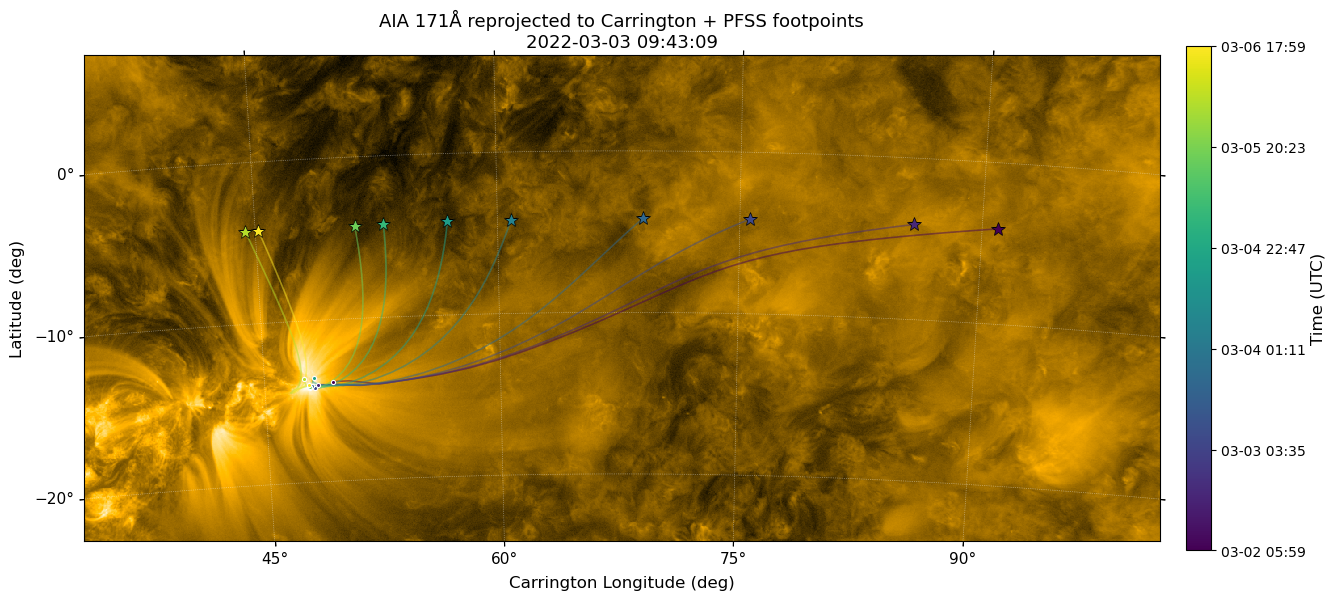

In [38]:
from astropy.wcs import WCS

# Determine footpoint bounding box in Carrington coordinates
fp_lon_vals = df['solar_fp_lon_deg'].dropna().values
fp_lat_vals = df['solar_fp_lat_deg'].dropna().values
ss_lon_vals = df['ss_lon_deg'].values

# Include both SS and solar footpoints in the bounding box
all_lons = np.concatenate([fp_lon_vals, ss_lon_vals])
all_lats = np.concatenate([fp_lat_vals, df['ss_lat_deg'].values])

pad_lon, pad_lat = 10, 10  # degrees padding
lon_min_box = all_lons.min() - pad_lon
lon_max_box = all_lons.max() + pad_lon
lat_min_box = all_lats.min() - pad_lat
lat_max_box = all_lats.max() + pad_lat
lon_center = (lon_min_box + lon_max_box) / 2
lat_center = (lat_min_box + lat_max_box) / 2
lon_range = lon_max_box - lon_min_box
lat_range = lat_max_box - lat_min_box

print(f"Footpoint region: lon={all_lons.min():.1f}-{all_lons.max():.1f}, "
      f"lat={all_lats.min():.1f}-{all_lats.max():.1f}")
print(f"Map center: ({lon_center:.1f}, {lat_center:.1f}), "
      f"range: {lon_range:.0f} x {lat_range:.0f} deg")

# Build a CAR (Plate Carree) WCS manually to avoid make_heliographic_header issues
scale = 0.05  # deg/pix
shape_out = (int(lat_range / scale), int(lon_range / scale))

carr_wcs = WCS(naxis=2)
carr_wcs.wcs.ctype = ['CRLN-CAR', 'CRLT-CAR']
carr_wcs.wcs.cdelt = [scale, scale]  # positive: lon increases left-to-right
carr_wcs.wcs.crpix = [shape_out[1] / 2 + 0.5, shape_out[0] / 2 + 0.5]
carr_wcs.wcs.crval = [lon_center, lat_center]
carr_wcs.wcs.cunit = ['deg', 'deg']
# Attach observer info needed for reprojection from HPC
carr_wcs.wcs.aux.dsun_obs = aia_map.meta['dsun_obs']
carr_wcs.wcs.aux.crln_obs = aia_map.meta.get('crln_obs', 0.0)
carr_wcs.wcs.aux.hglt_obs = aia_map.meta.get('hglt_obs', 0.0)
carr_wcs.wcs.dateobs = aia_map.meta['date-obs']
carr_wcs.wcs.set()

print(f"Output shape: {shape_out}")

# Reproject AIA to Carrington
aia_carr = aia_map.reproject_to(carr_wcs, shape_out=shape_out)

# --- Plot ---
plt.close('all')
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection=aia_carr)
aia_carr.plot(axes=ax)

# Plot field lines using plot_coord (Carrington frame matches the map)
for i, fline in enumerate(flines):
    coords = fline.coords
    coords_carr = SkyCoord(
        lon=coords.lon,
        lat=coords.lat,
        radius=coords.radius,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time)
    )
    ax.plot_coord(coords_carr, color=colors[i], alpha=0.5, linewidth=1.2)

# Plot solar surface footpoints
for i, fp in enumerate(solar_fps):
    if fp is None:
        continue
    fp_carr = SkyCoord(
        lon=fp.lon, lat=fp.lat, radius=1.0 * u.R_sun,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time)
    )
    ax.plot_coord(fp_carr, marker='o', color=colors[i], markersize=3,
                  markeredgecolor='white', markeredgewidth=0.8)

# Plot SS footpoints
for i in range(len(ss_lon)):
    ss_coord = SkyCoord(
        lon=ss_lon[i], lat=ss_lat[i], radius=rss * u.R_sun,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time)
    )
    ax.plot_coord(ss_coord, marker='*', color=colors[i], markersize=10,
                  markeredgecolor='black', markeredgewidth=0.5)

# Colorbar
sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm_cb, ax=ax, shrink=0.7, pad=0.02)
cbar_ticks = np.linspace(times_mjd.min(), times_mjd.max(), 6)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([Time(t, format='mjd').datetime.strftime('%m-%d %H:%M') for t in cbar_ticks])
cbar.set_label('Time (UTC)', fontsize=12)

ax.set_title(f'AIA 171\u00c5 reprojected to Carrington + PFSS footpoints\n'
             f'{obs_time.iso[:19]}', fontsize=13)
ax.set_xlabel('Carrington Longitude (deg)', fontsize=12)
ax.set_ylabel('Latitude (deg)', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/backmapping_timeseries_aia171_carrington.png', dpi=300)

## Plot 4: AIA 193Å reprojected to Carrington (flat view)

Same as Plot 3 but using 193Å channel, with smaller footpoint markers to resolve individual positions.

AIA 193 map center: (67.7, -9.1), range: 67 x 30 deg
Output shape: (601, 1332)


2026-03-31 23:25:00 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:25:00 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:25:00 - sunpy - WARNING: SunpyUserWarning: rsun mismatch detected: AIA 193.0 Angstrom 2022-03-03 09:43:04.rsun_meters=696000000.0 m;  2022-03-03 09:43:04.rsun_meters=695700000.0 m. This might cause unexpected results during reprojection.
2026-03-31 23:25:00 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-31 23:25:00 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


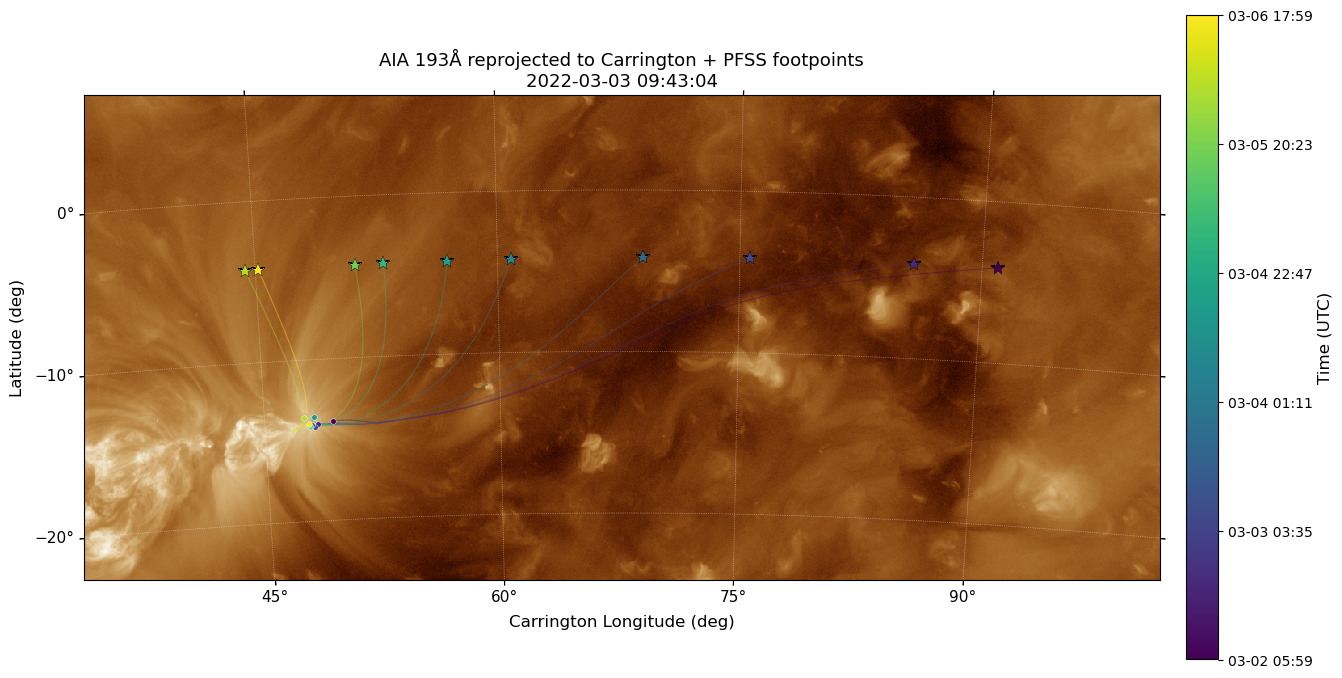

In [41]:
from astropy.wcs import WCS as _WCS

# Load AIA 193 map
aia193_map = sunpy.map.Map(DATA_DIR / 'aia.lev1_euv_12s.2022-03-03T094306Z.193.image_lev1.fits')
obs_time_193 = aia193_map.date

# Determine bounding box from footpoints (same logic as AIA 171 cell)
fp_lon_vals_193 = df['solar_fp_lon_deg'].dropna().values
fp_lat_vals_193 = df['solar_fp_lat_deg'].dropna().values
ss_lon_vals_193 = df['ss_lon_deg'].values

all_lons_193 = np.concatenate([fp_lon_vals_193, ss_lon_vals_193])
all_lats_193 = np.concatenate([fp_lat_vals_193, df['ss_lat_deg'].values])

pad_lon_193, pad_lat_193 = 10, 10
lon_center_193 = (all_lons_193.min() - pad_lon_193 + all_lons_193.max() + pad_lon_193) / 2
lat_center_193 = (all_lats_193.min() - pad_lat_193 + all_lats_193.max() + pad_lat_193) / 2
lon_range_193 = (all_lons_193.max() - all_lons_193.min()) + 2 * pad_lon_193
lat_range_193 = (all_lats_193.max() - all_lats_193.min()) + 2 * pad_lat_193

print(f"AIA 193 map center: ({lon_center_193:.1f}, {lat_center_193:.1f}), "
      f"range: {lon_range_193:.0f} x {lat_range_193:.0f} deg")

scale_193 = 0.05  # deg/pix (same as AIA 171)
shape_193 = (int(lat_range_193 / scale_193), int(lon_range_193 / scale_193))

carr_wcs_193 = _WCS(naxis=2)
carr_wcs_193.wcs.ctype = ['CRLN-CAR', 'CRLT-CAR']
carr_wcs_193.wcs.cdelt = [scale_193, scale_193]
carr_wcs_193.wcs.crpix = [shape_193[1] / 2 + 0.5, shape_193[0] / 2 + 0.5]
carr_wcs_193.wcs.crval = [lon_center_193, lat_center_193]
carr_wcs_193.wcs.cunit = ['deg', 'deg']
carr_wcs_193.wcs.aux.dsun_obs = aia193_map.meta['dsun_obs']
carr_wcs_193.wcs.aux.crln_obs = aia193_map.meta.get('crln_obs', 0.0)
carr_wcs_193.wcs.aux.hglt_obs = aia193_map.meta.get('hglt_obs', 0.0)
carr_wcs_193.wcs.dateobs = aia193_map.meta['date-obs']
carr_wcs_193.wcs.set()

print(f"Output shape: {shape_193}")

# Reproject AIA 193 to Carrington
aia193_carr = aia193_map.reproject_to(carr_wcs_193, shape_out=shape_193)

# --- Plot ---
plt.close('all')
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection=aia193_carr)
aia193_carr.plot(axes=ax)

# Plot field lines
for i, fline in enumerate(flines):
    coords = fline.coords
    coords_carr = SkyCoord(
        lon=coords.lon, lat=coords.lat, radius=coords.radius,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time_193)
    )
    ax.plot_coord(coords_carr, color=colors[i], alpha=0.4, linewidth=0.8)

# Plot solar surface footpoints — small markers to resolve overlap
for i, fp in enumerate(solar_fps):
    if fp is None:
        continue
    fp_carr = SkyCoord(
        lon=fp.lon, lat=fp.lat, radius=1.0 * u.R_sun,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time_193)
    )
    ax.plot_coord(fp_carr, marker='o', color=colors[i], markersize=4,
                  markeredgecolor='white', markeredgewidth=0.3)

# Plot SS footpoints — small stars
for i in range(len(ss_lon)):
    ss_coord = SkyCoord(
        lon=ss_lon[i], lat=ss_lat[i], radius=rss * u.R_sun,
        frame=HeliographicCarrington(observer='earth', obstime=obs_time_193)
    )
    ax.plot_coord(ss_coord, marker='*', color=colors[i], markersize=10,
                  markeredgecolor='black', markeredgewidth=0.3)

# Colorbar
sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm_cb, ax=ax, shrink=0.7, pad=0.02)
cbar_ticks = np.linspace(times_mjd.min(), times_mjd.max(), 6)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([Time(t, format='mjd').datetime.strftime('%m-%d %H:%M') for t in cbar_ticks])
cbar.set_label('Time (UTC)', fontsize=12)

ax.set_title(f'AIA 193\u00c5 reprojected to Carrington + PFSS footpoints\n'
             f'{obs_time_193.iso[:19]}', fontsize=13)
ax.set_xlabel('Carrington Longitude (deg)', fontsize=12)
ax.set_ylabel('Latitude (deg)', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/backmapping_timeseries_aia193_carrington.png', dpi=300)